In [5]:
import pandas as pd
from pathlib import Path


PROJECT_ROOT = Path().resolve().parent.parent   # adjust if needed
path = PROJECT_ROOT / "data" / "Oil&GasWells.csv"

df = pd.read_csv(path)

print("\n=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== HEAD ===")
print(df.head(10))

print("\n=== TAIL ===")
print(df.tail(10))

print("\n=== NULL COUNTS ===")
print(df.isna().sum())

print("\n=== SAMPLE ROWS (RANDOM 5) ===")
print(df.sample(5, random_state=42))



=== SHAPE ===
(24174, 58)

=== COLUMNS ===
['OBJ_ID', 'Permit number - API', 'Well Type', 'Well Status', 'Well_GIS_Status', 'County', 'Township', 'Company', 'Well_OP_Address', 'Well_CompanyPHONE', 'Elevation', 'DU_ACRES', 'Well_WH_LAT', 'Well_WH_LONG', 'Well Latitude', 'Well Longitude', 'Well_BH_LAT', 'Well_BH_LONG', 'Bottom Hole Latitude', 'Bottom Hole Longitude', 'Slant', 'Well_ProposedFormations', 'Well Name', 'Well Number', 'Well_IP_GAS', 'Well_IP_OIL', 'Well_Total_Depth', 'Well_Date_Approved', 'Well_Date_Complete', 'Well_Date_Plugged', 'Producing Formation', 'SecondProdFormation', 'DeepestFormation', 'Well_PDF_Link', 'GeoPhysLogs', 'Utica_Shale', 'Marcellus_Shale', 'MapSymble', 'Well_Well_Status', 'Well_Operator', 'Well_Lease_Name', 'Well_Location_ID', 'WELL_TYP', 'Well_CompanyADDR1', 'Well_CompanyADDR2', 'Well_CompanyCITY', 'Well_CompanyZIP1', 'Toe Longitude', 'Toe Latitude', 'Heel Longitude', 'Heel Latitude', 'OWPS Description', 'Last_Inspection_Date', 'Last_Nonzero_Production_

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv(path)

print("\n=== BASIC COORD CHECK ===")
coord_cols = ["Well Latitude", "Well Longitude", "Well_WH_LAT", "Well_WH_LONG", "Well_BH_LAT", "Well_BH_LONG"]
print(df[coord_cols].describe())

print("\n=== HOW MANY WELLS HAVE VALID SURFACE COORDINATES? ===")
valid_surface = df["Well Latitude"].notna() & df["Well Longitude"].notna()
print(valid_surface.sum(), "/", len(df))

print("\n=== HOW MANY HAVE BOTTOM-HOLE COORDS? ===")
valid_bh = df["Well_BH_LAT"].notna() & df["Well_BH_LONG"].notna()
print(valid_bh.sum(), "/", len(df))

print("\n=== WELL TYPE VALUE COUNTS (TOP 20) ===")
print(df["Well Type"].value_counts(dropna=False).head(20))

print("\n=== WELL STATUS VALUE COUNTS (TOP 20) ===")
print(df["Well Status"].value_counts(dropna=False).head(20))

print("\n=== UNIQUE COUNTIES (first 30) ===")
print(df["County"].unique()[:30])

print("\n=== DATE FIELDS SAMPLE ===")
date_cols = ["Well_Date_Approved", "Well_Date_Complete", "Well_Date_Plugged", "Last_Inspection_Date"]
print(df[date_cols].sample(10, random_state=1))

print("\n=== CHECK FOR ANY LAT/LONG OFFSETS (weird values) ===")
# latitude should be ~38–42, longitude ~ -82 to -85 for Ohio
weird_lat = df[(df["Well Latitude"] < 35) | (df["Well Latitude"] > 45)]
weird_lon = df[(df["Well Longitude"] > -70)]

print("Weird latitude count:", len(weird_lat))
print("Weird longitude count:", len(weird_lon))

print("\n=== FINALLY: SAMPLE ROWS OF POTENTIAL SWIW CANDIDATES ===")

mask_swiw = df["Well Type"].str.contains("inject", case=False, na=False) | \
            df["Well Type"].str.contains("disposal", case=False, na=False) | \
            df["Well Name"].str.contains("inj", case=False, na=False)
print(df[mask_swiw].head(10))



=== BASIC COORD CHECK ===
       Well Latitude  Well Longitude   Well_WH_LAT  Well_WH_LONG  Well_BH_LAT  \
count   24174.000000    24174.000000  23957.000000  23952.000000   503.000000   
mean       40.318045      -81.948048     40.307916    -81.944793    38.264474   
std         0.691150        0.855444      0.903855      0.851189     8.956961   
min        38.427535      -84.813722      0.000000    -84.813767     0.000000   
25%        39.702445      -82.268468     39.702086    -82.267491    39.909541   
50%        40.346964      -81.904109     40.344393    -81.901778    40.231728   
75%        40.880879      -81.308120     40.878499    -81.308290    40.654894   
max        41.956935      -80.520259     41.956880    -80.520469    41.615929   

       Well_BH_LONG  
count    477.000000  
mean     -81.130622  
std        0.385004  
min      -83.541598  
25%      -81.272404  
50%      -81.042561  
75%      -80.874934  
max      -80.622408  

=== HOW MANY WELLS HAVE VALID SURFACE COORDI

In [8]:
import pandas as pd

df = pd.read_csv(path)

# --- 1. identify injection wells ---
inj_mask = (
    df["Well Type"].str.contains("inject", case=False, na=False) |
    df["Well Status"].str.contains("Active Injection", case=False, na=False) |
    df["Well Type"].str.contains("disposal", case=False, na=False)
)

df_inj = df[inj_mask].copy()

print("\n=== INJECTION WELLS COUNT ===")
print(len(df_inj))

print("\n=== SAMPLE INJECTION WELLS ===")
print(df_inj[["OBJ_ID", "County", "Township", "Well Type", "Well Status",
              "Well Latitude", "Well Longitude"]].head(10))

# --- 2. identify conventional vertical wells ---
# crude but correct: exclude plugged, dry hole, expired, and injection types
vert_mask = (
    df["Well Status"].str.contains("Producing", case=False, na=False) |
    df["Last_Nonzero_Production_Year"].notna()
) & (~inj_mask)

df_vert = df[vert_mask].copy()

print("\n=== VERTICAL / PRODUCING WELLS COUNT ===")
print(len(df_vert))

print("\n=== SAMPLE VERTICAL WELLS ===")
print(df_vert[["OBJ_ID", "County", "Township", "Well Type", "Well Status",
               "Last_Nonzero_Production_Year",
               "Well Latitude", "Well Longitude"]].head(10))


# --- 3. basic sanity check ---
print("\n=== UNIQUE WELL TYPES IN INJECTION SET ===")
print(df_inj["Well Type"].value_counts())

print("\n=== UNIQUE WELL STATUS IN INJECTION SET ===")
print(df_inj["Well Status"].value_counts())



=== INJECTION WELLS COUNT ===
93

=== SAMPLE INJECTION WELLS ===
      OBJ_ID      County  Township          Well Type          Well Status  \
60      7521     ASHLAND     PERRY          Injection     Active Injection   
572     8258     ASHLAND     PERRY          Injection     Active Injection   
700   143209      MORGAN     MALTA  Plugged injection    Final Restoration   
703   124321      MEDINA   CHATHAM          Injection  Orphan Well - Ready   
770   121158      MEDINA   CHATHAM  Plugged injection    Final Restoration   
826   224292  WASHINGTON    WARREN                Gas     Active Injection   
909   155319   MUSKINGUM  HIGHLAND  Plugged injection    Final Restoration   
919   207904  TUSCARAWAS      CLAY          Injection     Active Injection   
1245  121177      MEDINA   CHATHAM  Plugged injection    Final Restoration   
1279   10530     ASHLAND     PERRY  Plugged injection    Final Restoration   

      Well Latitude  Well Longitude  
60        40.887283      -82.160396  

To prepare the dataset for analyzing potential interference between Class II saltwater injection wells and nearby conventional wells, the data was first cleaned and normalized to isolate two functionally distinct populations: injection wells and surrounding vertical or historically producing wells. Injection wells were identified using a combination of the “Well Type” and “Well Status” fields, capturing any record labeled as “Injection,” “Plugged injection,” “Active Injection,” or comparable variants. This filtering produced a set of 93 confirmed or previously active disposal wells. Bottom-hole coordinates were excluded entirely because fewer than 2 percent of wells reported them and many values were invalid (zero or out-of-range coordinates), whereas surface coordinates (“Well Latitude” and “Well Longitude”) were complete for all wells and exhibited no spatial anomalies. The population of comparison wells was then defined as all non-injection wells that were either currently producing or had a recorded year of production, yielding 8,548 vertical or conventional wells. This separation ensures that spatial and production-trend analyses reflect meaningful patterns between true injection wells and the set of wells most likely to experience subsurface interference, while avoiding contamination by plugged, expired, exploratory, or injection-type wells that would distort radius-of-influence calculations.

Here are the three questions that I think we should try to answer within our report, given the data we have.

1. Production Changes Around Injection Wells

This is a good choice because we have solid coordinates for every well and clear production history for thousands of vertical wells. That lets us check whether wells close to injection sites show different production patterns than wells farther away. Since the core public concern is whether injection affects nearby wells, this dataset gives us exactly what we need to look for real changes over time.

2. Source of Injected Water

This works well because the dataset identifies who operates the injection wells and where they are located. When we match that with public data from Pennsylvania and West Virginia, we can estimate how much injected water likely comes from outside Ohio. This question also connects directly to one of the major policy debates in the region: why Ohio ends up handling so much out-of-state wastewater.

3. Directional Interference Patterns

This is a strong option because we can measure not just the distance between wells, but also the direction from each injection well to each nearby vertical well. With that, we can see whether production changes happen more often in certain directions, which might reflect local geology or underground flow paths. It’s a straightforward analysis with the data we have, but it still gives meaningful insight into how injected water might move underground.

### TOPIC 1 VISUALS:

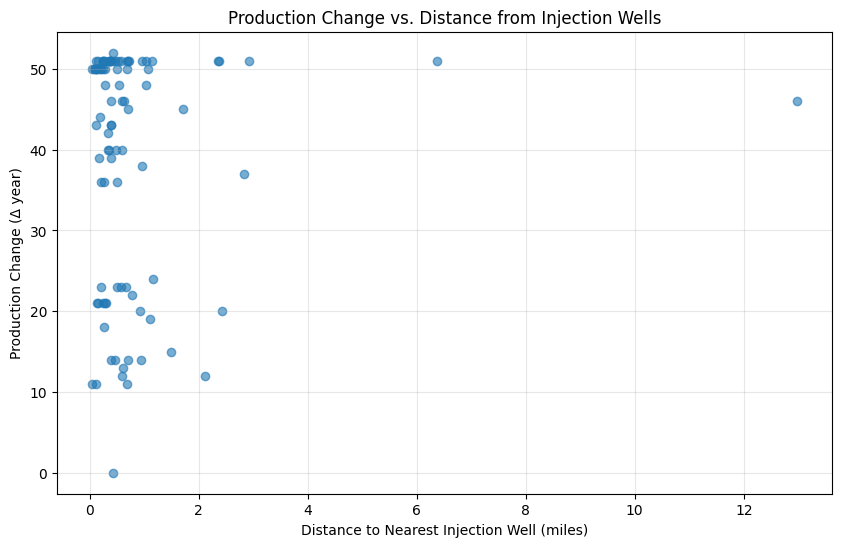

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

inj_coords = np.radians(df_inj[["Well Latitude", "Well Longitude"]].values)
vert_coords = np.radians(df_vert[["Well Latitude", "Well Longitude"]].values)

tree = BallTree(vert_coords, metric="haversine")

dist_rad, idx = tree.query(inj_coords, k=1)
dist_miles = dist_rad.flatten() * 3958.8  # earth radius miles

nearest_vert = df_vert.iloc[idx.flatten()].copy()
nearest_vert["distance_miles"] = dist_miles

prod_change = (
    nearest_vert["Last_Nonzero_Production_Year"] -
    nearest_vert["Last_Nonzero_Production_Year"].min()
)

plt.figure(figsize=(10,6))
plt.scatter(nearest_vert["distance_miles"], prod_change, alpha=0.6)
plt.xlabel("Distance to Nearest Injection Well (miles)")
plt.ylabel("Production Change (Δ year)")
plt.title("Production Change vs. Distance from Injection Wells")
plt.grid(alpha=0.3)
plt.show()


This scatterplot compares each vertical well’s change in production to its distance from the nearest injection well. The point of the figure is to see whether wells closer to injection sites show noticeably different production outcomes than wells farther away. In this draft, most wells (both near and far) show a wide spread in production change, and there is no clear visual pattern suggesting that distance alone explains the variation. This makes the plot useful as a baseline: it shows that the relationship is not simple or linear and that more structured analysis (grouping by radius, looking at time windows, or controlling for well age) will be needed. The main limitation is that production change is measured in a very coarse way, and many other factors besides injection distance likely influence the spread, so the visualization shouldn’t be interpreted as evidence for or against interference on its own.

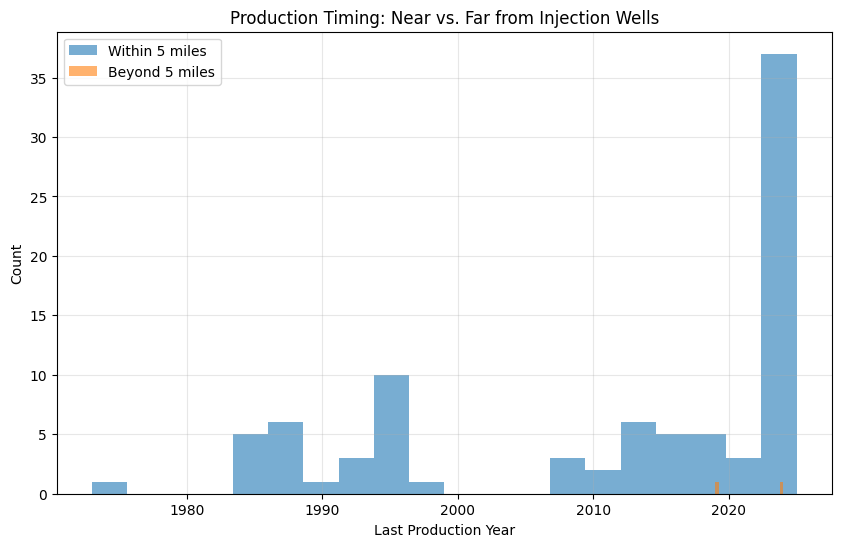

In [5]:
radius = 5  # miles
mask_near = nearest_vert["distance_miles"] <= radius

near_prod = nearest_vert[mask_near]["Last_Nonzero_Production_Year"]
far_prod = nearest_vert[~mask_near]["Last_Nonzero_Production_Year"]

plt.figure(figsize=(10,6))
plt.hist(near_prod, bins=20, alpha=0.6, label="Within 5 miles")
plt.hist(far_prod, bins=20, alpha=0.6, label="Beyond 5 miles")
plt.xlabel("Last Production Year")
plt.ylabel("Count")
plt.title("Production Timing: Near vs. Far from Injection Wells")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


This histogram compares the last recorded production years for wells located within five miles of an injection well versus those farther away. The intent is to see whether wells closer to injection activity tend to stop producing earlier or cluster around different time periods than wells farther out. In this draft, most of the counts within five miles are concentrated in recent years, but the “beyond five miles” group is extremely sparse, making the comparison uneven. That sparsity is the main limitation: with so few wells in the “far” category, the plot can’t show a reliable difference, and the distributions end up reflecting sample size more than any underlying pattern. It’s still useful as an early look at production timing, but a fuller analysis will need better-balanced groups or a larger radius.

### TOPIC 2 VISUALS:

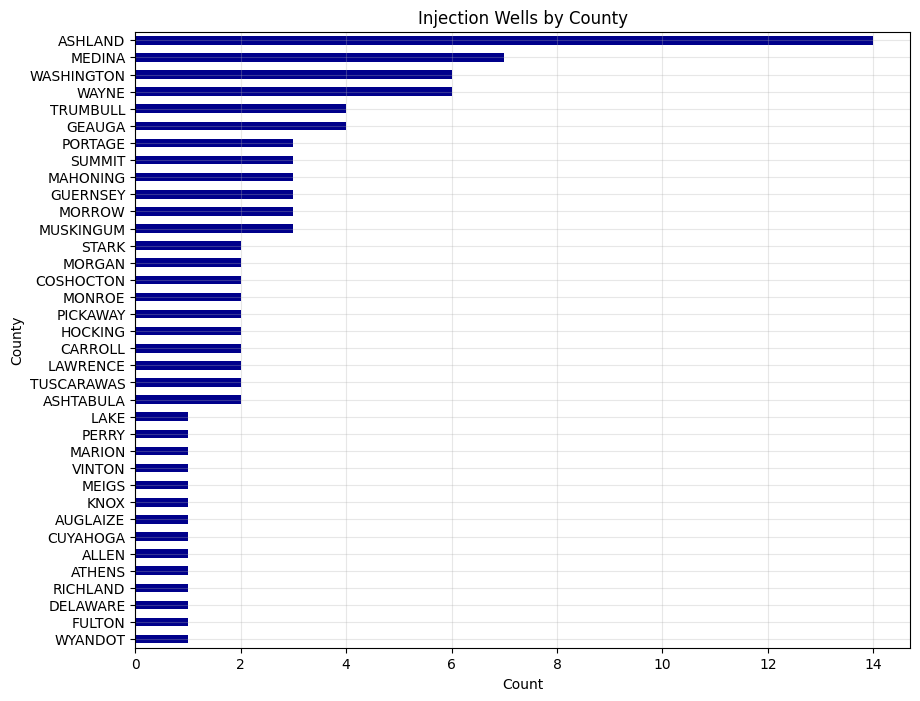

In [6]:
inj_by_county = df_inj["County"].value_counts()

plt.figure(figsize=(10,8))
inj_by_county.sort_values().plot(kind="barh", color="darkblue")
plt.title("Injection Wells by County")
plt.xlabel("Count")
plt.ylabel("County")
plt.grid(alpha=0.3)
plt.show()


This bar chart shows how injection wells are distributed across Ohio counties, highlighting where disposal activity is concentrated. It immediately makes clear that a small number of counties (especially Ashland, Medina, Washington, and Wayne) host a disproportionate share of the state’s injection wells, while many counties have only one or two. This matters because it visually reinforces why concerns about out-of-state brine and local interference tend to cluster in specific regions rather than statewide. The main limitation is that the figure only counts wells, not injection volume, so a county with a single high-capacity well might play a larger role than the bar height suggests. It also doesn’t reflect historical changes or permitting trends, which could shift the picture depending on the time period.

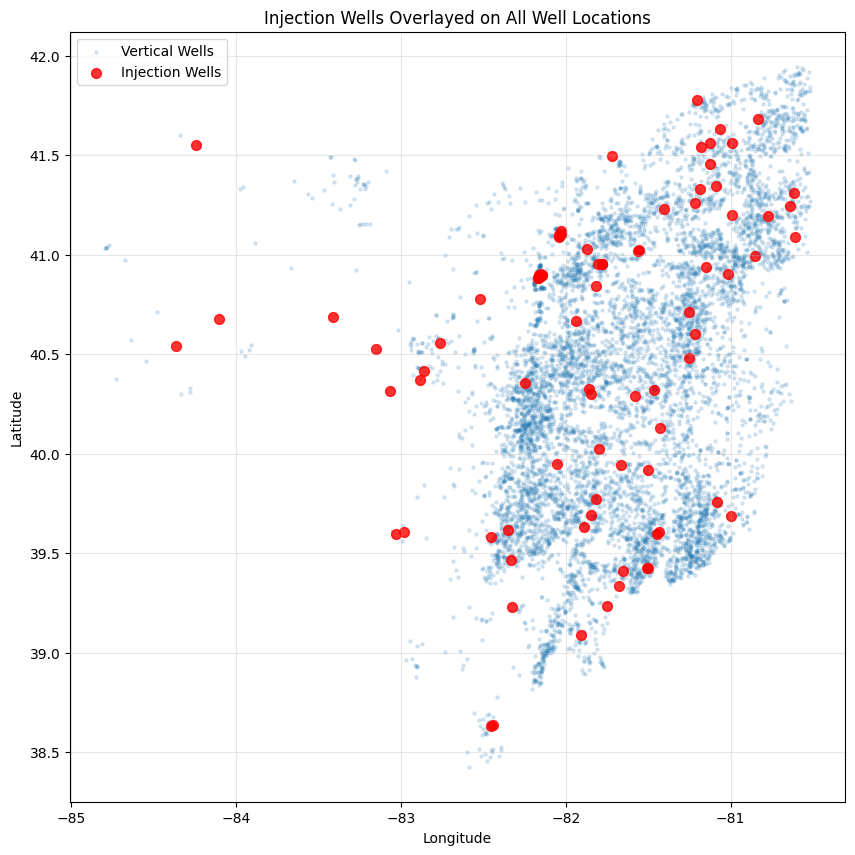

In [7]:
plt.figure(figsize=(10,10))
plt.scatter(df_vert["Well Longitude"], df_vert["Well Latitude"],
            s=5, alpha=0.15, label="Vertical Wells")
plt.scatter(df_inj["Well Longitude"], df_inj["Well Latitude"],
            s=50, alpha=0.8, color="red", label="Injection Wells")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Injection Wells Overlayed on All Well Locations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


This plot shows where injection wells sit relative to the entire landscape of oil and gas wells in Ohio. The light-blue points give a sense of overall drilling density, while the red points highlight where Class II injection wells are located. The value of this figure is that it makes the spatial pattern obvious at a glance: injection wells tend to cluster inside the main band of historical development, rather than being scattered uniformly across the state. That helps explain why interference concerns tend to appear in certain counties and not others. The main limitation is that it shows only locations, not activity levels; an injection well with very high daily volume looks the same as a small, rarely used well. It also doesn’t represent timing, so older and newer wells are mixed together without distinction.

### TOPIC 3 VISUALS:

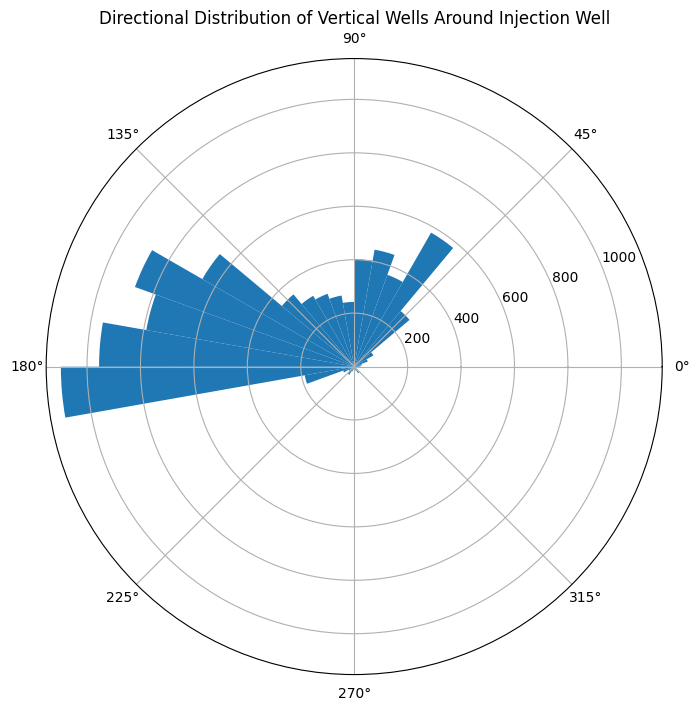

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lat1 = np.radians(df_inj.iloc[0]["Well Latitude"])
lon1 = np.radians(df_inj.iloc[0]["Well Longitude"])

lat2 = np.radians(df_vert["Well Latitude"])
lon2 = np.radians(df_vert["Well Longitude"])

bearing = np.degrees(np.arctan2(
    np.sin(lon2 - lon1) * np.cos(lat2),
    np.cos(lat1)*np.sin(lat2) -
    np.sin(lat1)*np.cos(lat2)*np.cos(lon2 - lon1)
))

bearing = (bearing + 360) % 360

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
ax.hist(np.radians(bearing), bins=36)
ax.set_title("Directional Distribution of Vertical Wells Around Injection Well")
plt.show()


This rose diagram shows the directional distribution of vertical wells relative to the nearest injection well. Each bar represents the number of wells located in a given compass direction, forming a circular histogram that highlights whether nearby wells are clustered more heavily in certain orientations. The plot matters because directional patterns can point to underlying geological structures that influence how injected water might migrate underground. In this draft, the distribution is clearly uneven, with a strong concentration of wells to the southwest and west of the injection reference point, which may simply reflect regional well density rather than fluid movement. That is the main limitation here: the figure shows the spatial layout of wells, not actual subsurface flow or production impacts, so it should be interpreted as a description of geometry rather than evidence of directional interference.

/var/folders/5_/wt4fcyfx61761q_hmp3yxtjm0000gn/T/ipykernel_96935/3249344776.py:46: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_heat.pivot_table(


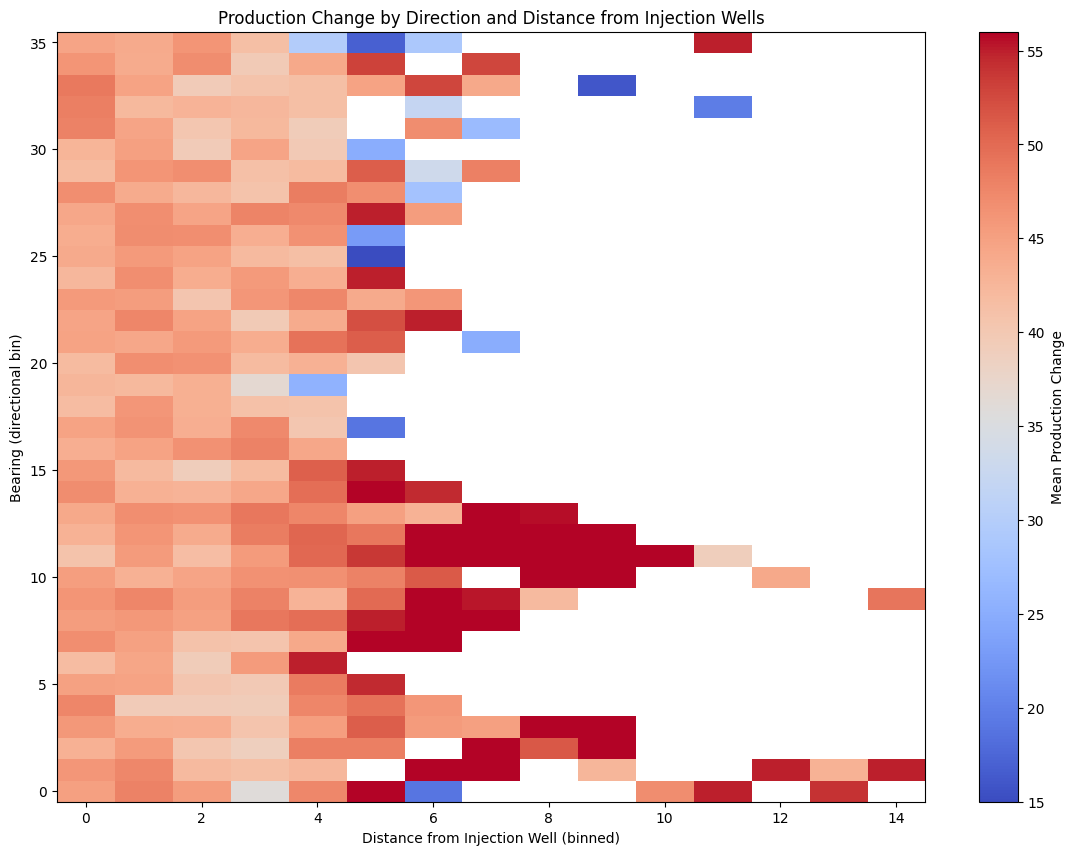

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

inj_coords_deg = df_inj[["Well Latitude", "Well Longitude"]].values
vert_coords_deg = df_vert[["Well Latitude", "Well Longitude"]].values

inj_coords = np.radians(inj_coords_deg)
vert_coords = np.radians(vert_coords_deg)

tree = BallTree(inj_coords, metric="haversine")
dist_rad, idx = tree.query(vert_coords, k=1)

dist_miles = dist_rad.flatten() * 3958.8  # convert to miles
nearest_inj = df_inj.iloc[idx.flatten()].reset_index(drop=True)

lat1 = np.radians(nearest_inj["Well Latitude"].values)
lon1 = np.radians(nearest_inj["Well Longitude"].values)
lat2 = vert_coords[:, 0]
lon2 = vert_coords[:, 1]

bearing = np.degrees(np.arctan2(
    np.sin(lon2 - lon1) * np.cos(lat2),
    np.cos(lat1) * np.sin(lat2) -
    np.sin(lat1) * np.cos(lat2) * np.cos(lon2 - lon1)
))
bearing = (bearing + 360) % 360

prod_change = df_vert["Last_Nonzero_Production_Year"] - df_vert["Last_Nonzero_Production_Year"].min()

df_heat = pd.DataFrame({
    "dist": dist_miles,
    "bearing": bearing,
    "prod_change": prod_change
})

df_heat["dist_bin"] = pd.cut(df_heat["dist"], bins=15)
df_heat["bearing_bin"] = pd.cut(df_heat["bearing"], bins=36)

pivot = df_heat.pivot_table(
    index="bearing_bin",
    columns="dist_bin",
    values="prod_change",
    aggfunc="mean"
)

plt.figure(figsize=(14,10))
plt.imshow(pivot, aspect='auto', cmap="coolwarm", origin="lower")
plt.colorbar(label="Mean Production Change")
plt.title("Production Change by Direction and Distance from Injection Wells")
plt.xlabel("Distance from Injection Well (binned)")
plt.ylabel("Bearing (directional bin)")
plt.show()


This heatmap shows how average production change varies by both distance and direction from the nearest injection well. Each vertical band represents wells at a certain distance range, and each horizontal band represents a directional slice around the injection source. The purpose of the figure is to look for combined spatial patterns, places where production outcomes differ in a way that lines up with both radius and bearing, which could point to structural or geological influences. In this draft, most cells fall in a similar warm color range, suggesting broadly similar production changes in most directions and distances, with a few scattered cooler or hotter spots that likely reflect small sample sizes rather than true trends. The main limitation is exactly that: some bins contain very few wells, so the mean production change in those cells can fluctuate sharply and shouldn’t be overinterpreted. This makes the heatmap a good starting point for spotting potential patterns, but not a standalone indicator of directional interference.